# Análisis Exploratorio de Datos (EDA): Gestión del Riesgo Crediticio
## Caso de Negocio: Incremento de Mora en Fintech - Norte Argentino

### Contexto del Negocio:
Una empresa fintech que otorga microcréditos en el norte argentino ha registrado un **incremento en la tasa de mora** durante el último semestre. Este fenómeno ha generado gran preocupación en el directorio, ya que impacta de manera directa en la rentabilidad y sostenibilidad del negocio.

### Objetivo del Análisis:
El propósito de este notebook es realizar un Análisis Exploratorio de Datos (EDA) orientado a los negocios para:
1. **Identificar los factores clave** (demográficos, financieros e históricos) que correlacionan con la probabilidad de mora.
2. **Evaluar la efectividad del actual sistema de evaluación de riesgo** (credit score y categorización de historial).
3. **Proporcionar recomendaciones accionables** para mitigar la mora y proteger el margen de ganancia de la fintech.

---

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos visuales premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Cargar datos del dataset
file_path = 'data/raw/fintech_base_150_registros.xlsx'
df = pd.read_excel(file_path)
print(f"Base cargada exitosamente: {df.shape[0]} clientes y {df.shape[1]} variables.")

Base cargada exitosamente: 150 clientes y 13 variables.


## 1. Limpieza y Validación de Datos

Para garantizar la calidad de nuestras conclusiones para el directorio, verificamos y corregimos inconsistencias en el dataset:
- Chequeo de nulos y duplicados.
- Estandarización de texto (eliminar espacios, uniformar capitalización).
- Creación de variables categóricas descriptivas para mejorar la legibilidad de los reportes.
- Validaciones lógicas en variables financieras.

In [9]:
# 1. Chequeo de Nulos
print("--- Valores Nulos Faltantes ---")
print(df.isnull().sum())

# 2. Chequeo de Duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados detectados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print("Registros duplicados eliminados.")

# 3. Estandarización de Variables de Texto
for col in ['nivel_educativo', 'zona', 'historial_crediticio']:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

# 4. Mapear estado de mora para reportes de negocio
df['estado_cliente'] = df['mora'].map({0: 'Al día', 1: 'En Mora'})

# 5. Validaciones lógicas de consistencia numérica
edad_anomala = df[df['edad'] <= 0].shape[0]
ingreso_anomalo = df[df['ingreso_mensual'] < 0].shape[0]
monto_anomalo = df[df['monto_credito'] <= 0].shape[0]
print(f"\nRegistros con inconsistencias: Edad ({edad_anomala}), Ingreso ({ingreso_anomalo}), Monto ({monto_anomalo})")

print("\n--- Estructura del dataset limpio ---")
df.info()

--- Valores Nulos Faltantes ---
id_cliente              0
edad                    0
ingreso_mensual         0
monto_credito           0
cuotas                  0
tasa_interes            0
antiguedad_laboral      0
nivel_educativo         0
zona                    0
historial_crediticio    0
atrasos_previos         0
score_crediticio        0
mora                    0
dtype: int64

Registros duplicados detectados: 0

Registros con inconsistencias: Edad (0), Ingreso (0), Monto (0)

--- Estructura del dataset limpio ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            150 non-null    int64  
 1   edad                  150 non-null    int64  
 2   ingreso_mensual       150 non-null    int64  
 3   monto_credito         150 non-null    int64  
 4   cuotas                150 non-null    int64  
 5   tasa_interes         

## 2. Diagnóstico de la Cartera de Microcréditos

Calculamos estadísticas descriptivas globales y el comportamiento del cliente según su cumplimiento actual.

In [10]:
# Resumen global de variables cuantitativas
print("--- Estadísticas Generales de Clientes ---")
display(df.describe())

# Tasa de mora global (Tasa de default)
tasa_default = df['mora'].mean() * 100
print(f"\nTASA DE MORA GLOBAL (DEFAULT): {tasa_default:.2f}%")

# Comparativa de promedios entre clientes al día y en mora
print("\n--- Comparativa de Medios por Estado de Mora ---")
analisis_mora = df.groupby('estado_cliente')[[
    'edad', 'ingreso_mensual', 'monto_credito', 
    'tasa_interes', 'score_crediticio', 'atrasos_previos', 'antiguedad_laboral'
]].mean()
display(analisis_mora)

--- Estadísticas Generales de Clientes ---


,id_cliente,edad,ingreso_mensual,monto_credito,cuotas,tasa_interes,antiguedad_laboral,atrasos_previos,score_crediticio,mora
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,38.780000,447156.940000,290989.693333,7.393333,49.246000,10.200000,2.486667,583.753333,0.500000
std,43.445368,12.974353,204064.605553,136768.608453,2.837658,17.009103,5.838268,1.709573,160.892558,0.501675
min,1.000000,18.000000,109230.000000,50581.000000,3.000000,20.140000,0.200000,0.000000,302.000000,0.000000
25%,38.250000,28.250000,268406.250000,185755.000000,5.000000,33.465000,5.500000,1.000000,454.750000,0.000000
50%,75.500000,37.000000,446532.500000,298546.000000,7.500000,48.625000,10.850000,3.000000,580.500000,0.500000
75%,112.750000,49.500000,645121.500000,417013.500000,9.750000,63.385000,15.375000,4.000000,716.500000,1.000000
max,150.000000,65.000000,786913.000000,498558.000000,12.000000,79.780000,19.600000,5.000000,899.000000,1.000000



TASA DE MORA GLOBAL (DEFAULT): 50.00%

--- Comparativa de Medios por Estado de Mora ---


,edad,ingreso_mensual,monto_credito,tasa_interes,score_crediticio,atrasos_previos,antiguedad_laboral
estado_cliente,,,,,,,
Al día,38.933333,460018.00,273325.653333,47.458,593.093333,1.880000,10.14
En Mora,38.626667,434295.88,308653.733333,51.034,574.413333,3.093333,10.26


## 3. Polígono de Frecuencias

Analizamos cómo se distribuye la población de la fintech según su **Edad** e **Ingreso Mensual**, comparando a los clientes que están al día frente a los que están en mora.

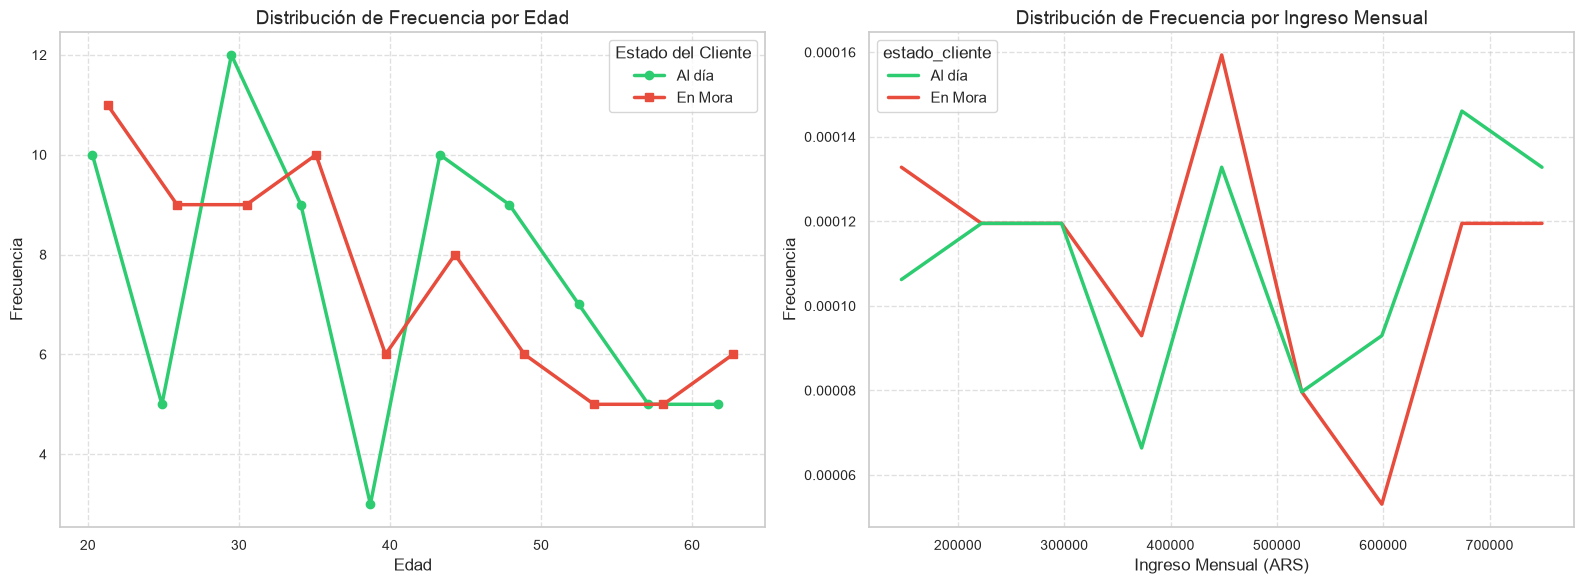

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Polígono de Frecuencia para Edad (Construcción Manual)
counts_ok, edges_ok = np.histogram(df[df['mora'] == 0]['edad'], bins=10)
counts_mora, edges_mora = np.histogram(df[df['mora'] == 1]['edad'], bins=10)

centers_ok = (edges_ok[:-1] + edges_ok[1:]) / 2
centers_mora = (edges_mora[:-1] + edges_mora[1:]) / 2

axes[0].plot(centers_ok, counts_ok, marker='o', label='Al día', color='#2ecc71', linewidth=2.5)
axes[0].plot(centers_mora, counts_mora, marker='s', label='En Mora', color='#e74c3c', linewidth=2.5)
axes[0].set_title('Distribución de Frecuencia por Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title="Estado del Cliente")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Polígono de Frecuencia para Ingreso Mensual (Usando Seaborn)
sns.histplot(
    data=df, 
    x='ingreso_mensual', 
    hue='estado_cliente', 
    element='poly', 
    fill=False, 
    stat='frequency', 
    common_norm=False, 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    linewidth=2.5, 
    ax=axes[1]
)
axes[1].set_title('Distribución de Frecuencia por Ingreso Mensual')
axes[1].set_xlabel('Ingreso Mensual (ARS)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Diagrama de Caja (Box Plot)

Evaluamos la dispersión y la efectividad del actual score crediticio para predecir la mora, además de la relación con los ingresos mensuales.

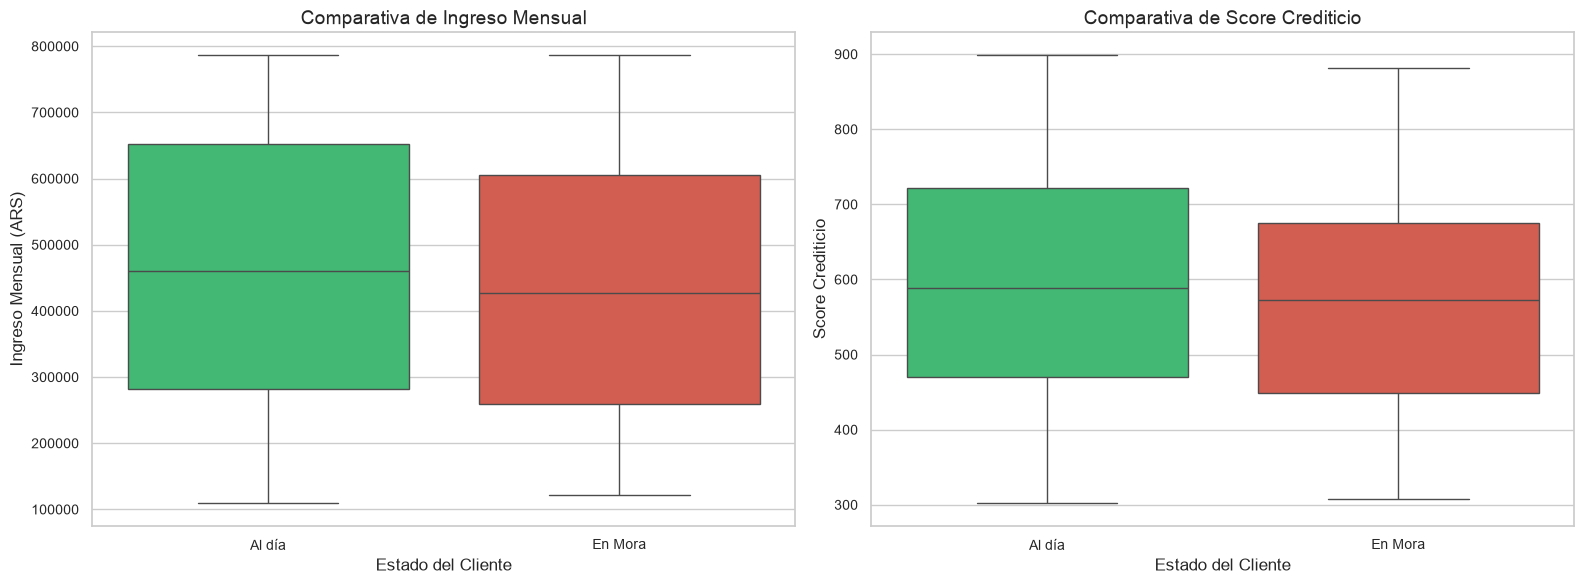

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot para Ingreso Mensual
sns.boxplot(
    data=df, 
    x='estado_cliente', 
    y='ingreso_mensual', 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    hue='estado_cliente', 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Comparativa de Ingreso Mensual')
axes[0].set_xlabel('Estado del Cliente')
axes[0].set_ylabel('Ingreso Mensual (ARS)')

# Boxplot para Score Crediticio
sns.boxplot(
    data=df, 
    x='estado_cliente', 
    y='score_crediticio', 
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'}, 
    hue='estado_cliente', 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Comparativa de Score Crediticio')
axes[1].set_xlabel('Estado del Cliente')
axes[1].set_ylabel('Score Crediticio')

plt.tight_layout()
plt.show()

## 5. Diagrama de Dispersión (Scatter Plot)

Analizamos la relación conjunta entre el **Ingreso Mensual** del cliente y el **Monto del Crédito** solicitado, identificando visualmente zonas críticas de incumplimiento.

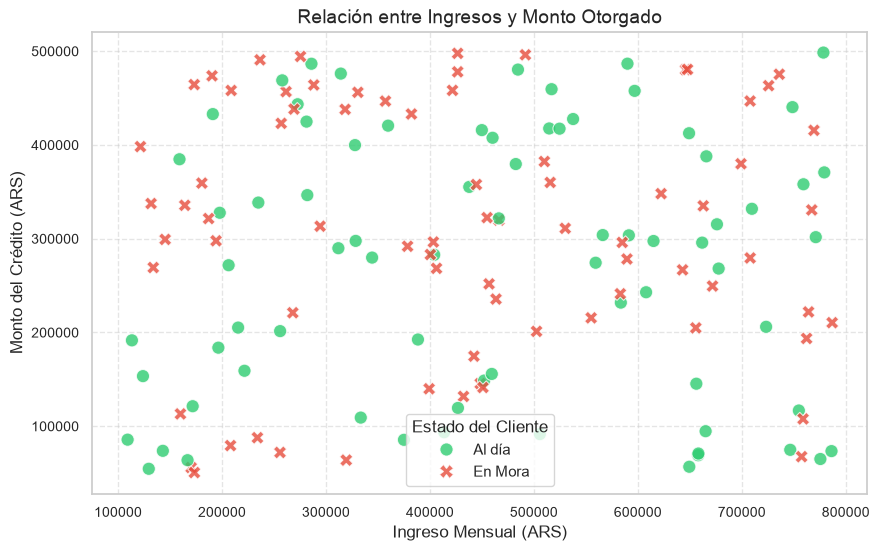

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='ingreso_mensual', 
    y='monto_credito', 
    hue='estado_cliente', 
    style='estado_cliente',
    palette={'Al día': '#2ecc71', 'En Mora': '#e74c3c'},
    alpha=0.8,
    s=90
)

plt.title('Relación entre Ingresos y Monto Otorgado')
plt.xlabel('Ingreso Mensual (ARS)')
plt.ylabel('Monto del Crédito (ARS)')
plt.legend(title='Estado del Cliente')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6. Análisis Segmentado por Categorías (Diagnóstico de Riesgo)

A continuación, investigamos en detalle cómo varía la tasa de mora real según:
1. **Zona Geográfica:** Verificamos el comportamiento por zonas (urbana, periurbana, rural).
2. **Clasificación del Historial Crediticio:** Evaluamos si la categorización actual (Bueno, Regular, Malo) clasifica correctamente el riesgo del cliente.

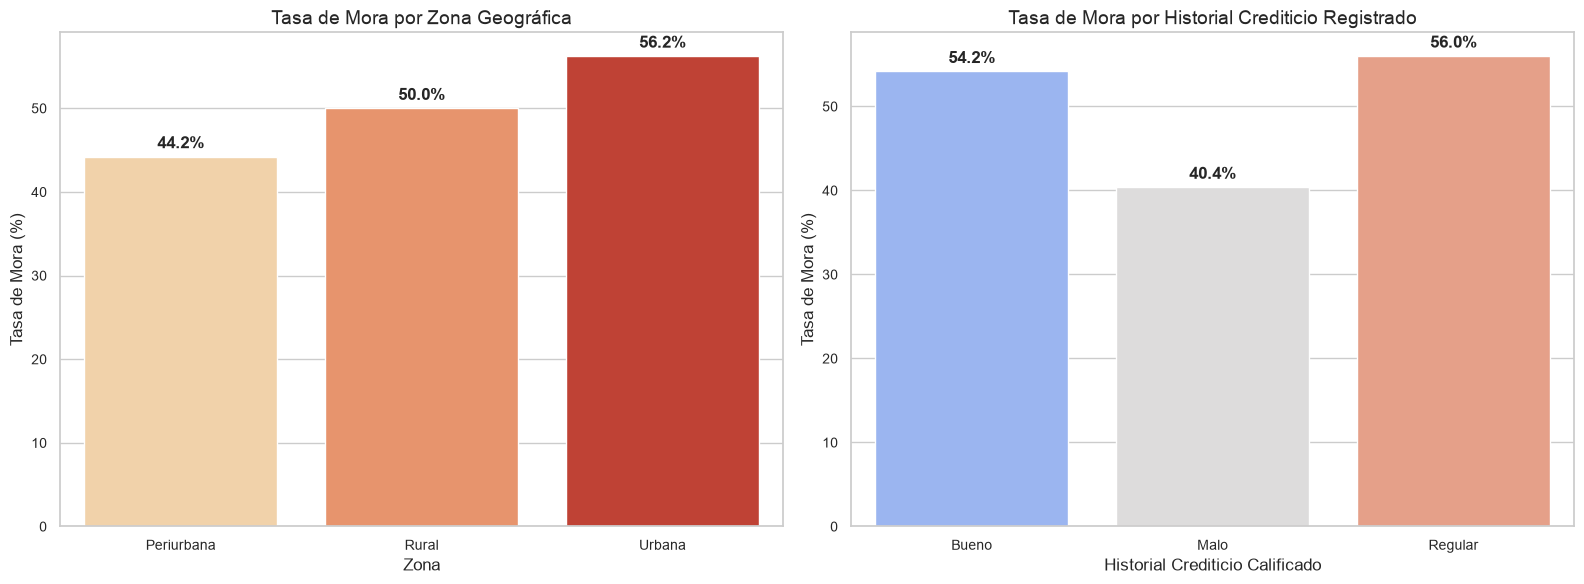

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tasa de Mora por Zona Geográfica
mora_zona = df.groupby('zona')['mora'].mean() * 100
sns.barplot(
    x=mora_zona.index, 
    y=mora_zona.values, 
    palette='OrRd', 
    hue=mora_zona.index, 
    legend=False, 
    ax=axes[0]
)
axes[0].set_title('Tasa de Mora por Zona Geográfica')
axes[0].set_xlabel('Zona')
axes[0].set_ylabel('Tasa de Mora (%)')
for i, val in enumerate(mora_zona.values):
    axes[0].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

# 2. Tasa de Mora por Clasificación de Historial Crediticio
mora_hist = df.groupby('historial_crediticio')['mora'].mean() * 100
sns.barplot(
    x=mora_hist.index, 
    y=mora_hist.values, 
    palette='coolwarm', 
    hue=mora_hist.index, 
    legend=False, 
    ax=axes[1]
)
axes[1].set_title('Tasa de Mora por Historial Crediticio Registrado')
axes[1].set_xlabel('Historial Crediticio Calificado')
axes[1].set_ylabel('Tasa de Mora (%)')
for i, val in enumerate(mora_hist.values):
    axes[1].text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Matriz de Correlación

Calculamos las correlaciones cuantitativas de las variables para verificar cuáles tienen un vínculo directo con la variable `mora`.

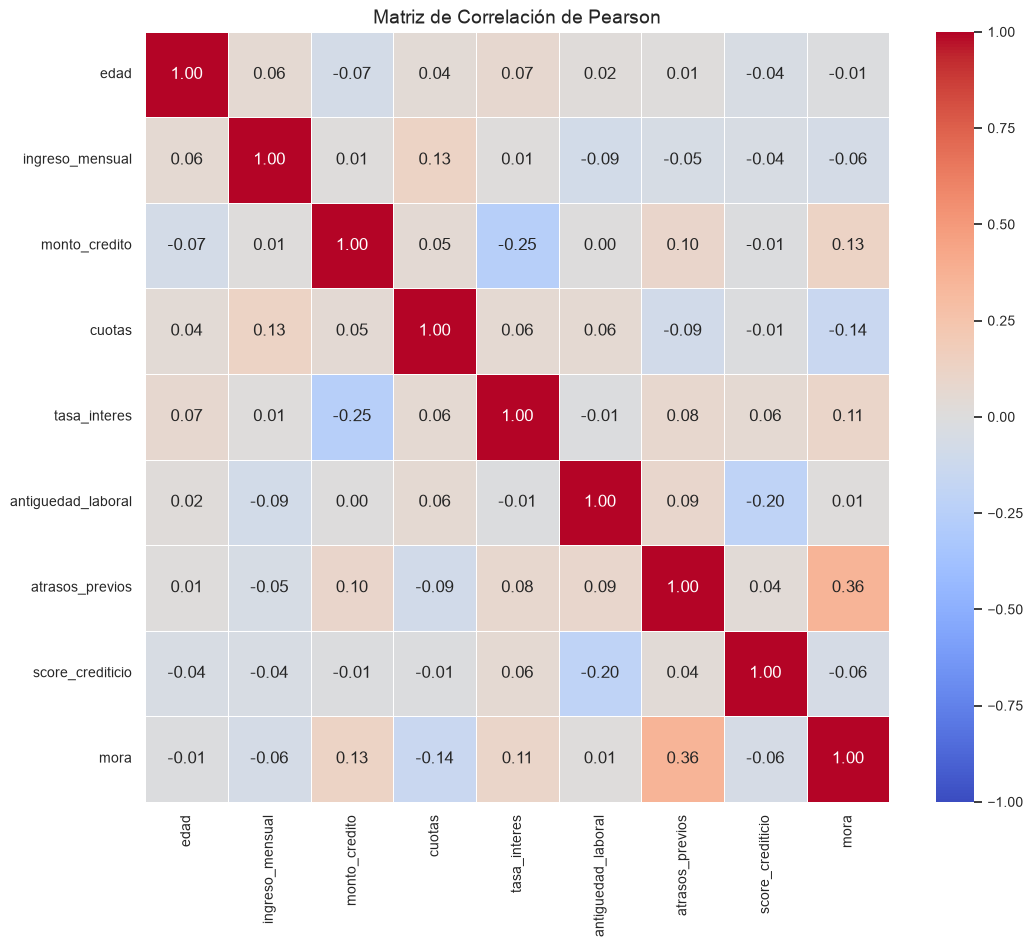

In [15]:
num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'id_cliente']
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)
plt.title('Matriz de Correlación de Pearson')
plt.show()

## 8. Conclusiones y Propuestas para el Directorio

Basándonos en el análisis exploratorio de datos, presentamos los principales hallazgos y propuestas estratégicas:

### **Hallazgos Clave (Diagnósticos):**
1. **Falla Crítica en el Sistema de Scoring / Historial:**
   * **Inconsistencia del Historial:** Los clientes con historial crediticio registrado como **"Bueno"** muestran una tasa de mora del **54.2%**, mientras que aquellos catalogados con historial **"Malo"** tienen una mora menor (**40.4%**). Esto indica que los criterios actuales para etiquetar el historial crediticio son ineficaces o están invertidos.
   * **Poca diferenciación por Score:** La diferencia de score promedio entre clientes al día ($593.1$) y clientes en mora ($574.4$) es de apenas $19$ puntos. El score actual no está segmentando con precisión el riesgo.
2. **Atrasos Previos como Indicador Clave de Riesgo:**
   * Los clientes que cayeron en mora promedian **3.1 atrasos previos**, en comparación con **1.9 atrasos** de los clientes que están al día. Esta variable muestra una relación mucho más directa con la mora futura que la calificación de historial.
3. **Presión Financiera (Monto y Tasa de Interés):**
   * Los clientes en mora recibieron créditos de mayor monto promedio ($308,653$ ARS vs. $273,325$ ARS de los que están al día) y con tasas de interés promedio más elevadas ($51.0\%$ vs. $47.5\%$).
4. **Riesgo por Zonas:**
   * La **Zona Urbana** presenta la tasa de mora más alta con un **56.2%**, seguida por la **Zona Rural** con **50.0%** y la **Zona Periurbana** con **44.2%**.

### **Propuestas Estratégicas para Mitigación:**
* **Recalibrar el Motor de Scoring:** Se debe auditar y reconstruir la regla de clasificación del "historial crediticio". Es urgente redefinir qué constituye un cliente con historial "Bueno" y "Malo".
* **Restricción de Montos en Función del Ingreso:** Establecer límites máximos de crédito en base a la relación cuota/ingreso mensual, especialmente para montos superiores a $300,000$ ARS.
* **Ponderación de Atrasos Recientes:** El motor de aprobación automática debe penalizar fuertemente a los postulantes con más de $2$ atrasos previos, ya que esta variable es el indicador empírico más robusto en el comportamiento de pago.
* **Ajuste de Políticas por Zona:** Reforzar las políticas de cobro y límites de crédito inicial en la Zona Urbana (la de mayor incumplimiento).